# 100 m hydrological connectivity (Tasmania)

This notebook adapts the staged workflow in `03alt3_hydrological_connectivity` to all of Tasmania on a 100 m grid. It uses the statewide DEM, mapped Watercourses, and the statewide Karst Atlas polygon layer. The 100 m DEM will be prepared from the statewide DEM as a later stage; subsequent stages will follow the same sequence as `03alt3`, with outputs named `tas_100m` to keep them separate from Mole Creek and other statewide products.


## 1. Set paths and inspect the statewide inputs

Resolve the project data directory and identify the statewide 100 m DEM, Watercourse GeoPackage, and prepared statewide Karst Atlas polygons. Check that the inputs exist, use EPSG:7855, and inspect the DEM grid and vector feature counts before processing.


In [ ]:
from pathlib import Path
import os

import geopandas as gpd
import pandas as pd
import numpy as np
import rasterio

# Resolve project root and data directory using the repository convention.
working_dir = Path.cwd()
project_root = working_dir.parent if working_dir.name == "notebooks" else working_dir
data_dir_value = os.environ.get("AT3_DATA_DIR")
if not data_dir_value:
    env_file = project_root / ".env"
    if env_file.exists():
        for line in env_file.read_text(encoding="utf-8-sig").splitlines():
            entry = line.strip()
            if entry.startswith("AT3_DATA_DIR="):
                data_dir_value = entry.split("=", 1)[1].strip().strip('\"').strip("'")
                break

data_path = Path(data_dir_value).expanduser() if data_dir_value else project_root / "data"
if not data_path.is_absolute():
    data_path = (project_root / data_path).resolve()
output_path = data_path / "Output_data"

dem_tas_100m_path = output_path / "dem_tas_100m_EPSG7855.tif"
watercourse_gpkg_path = output_path / "watercourses_tas_EPSG7855.gpkg"
karst_atlas_gpkg_path = output_path / "karst_tas_EPSG7855.gpkg"
required_paths = (dem_tas_100m_path, watercourse_gpkg_path, karst_atlas_gpkg_path)
missing_paths = [path for path in required_paths if not path.is_file()]
if missing_paths:
    missing_list = "\n".join(f"  - {path}" for path in missing_paths)
    raise FileNotFoundError(f"Required statewide inputs are missing:\n{missing_list}")

with rasterio.open(dem_tas_100m_path) as dem_src:
    if dem_src.count != 1:
        raise ValueError(f"Expected a single-band 100 m DEM: {dem_tas_100m_path}")
    if dem_src.crs is None or dem_src.crs.to_epsg() != 7855:
        raise ValueError(f"Expected the DEM in EPSG:7855; found {dem_src.crs}")
    if not np.allclose(dem_src.res, (100.0, 100.0), rtol=0, atol=1e-6):
        raise ValueError(f"Expected 100 m DEM cells; found resolution {dem_src.res}")
    dem_grid = (dem_src.shape, dem_src.crs, dem_src.transform, dem_src.res)
    dem_bounds = dem_src.bounds
    dem_profile = dem_src.profile.copy()
    dem_nodata = dem_src.nodata
    valid_dem = dem_src.dataset_mask() > 0
    dem_values = dem_src.read(1, masked=True)
    valid_dem &= ~np.ma.getmaskarray(dem_values) & np.isfinite(dem_values.data)

if not valid_dem.any():
    raise ValueError("The 100 m DEM contains no valid elevation cells")

print(f"100 m DEM: {dem_tas_100m_path}")
print(f"CRS: {dem_grid[1]}; shape: {dem_grid[0]}; resolution: {dem_grid[3]}")
print(f"Bounds: {dem_bounds}; valid cells: {int(valid_dem.sum()):,}")
print(f"Output directory: {output_path}")

watercourses = gpd.read_file(watercourse_gpkg_path)
karst_atlas = gpd.read_file(karst_atlas_gpkg_path)
for label, layer in (("Watercourses", watercourses), ("Karst Atlas", karst_atlas)):
    if layer.crs is None:
        raise ValueError(f"{label} layer has no CRS")
    print(f"{label}: {len(layer):,} features ({layer.crs})")
    if str(layer.crs).upper() != str(dem_crs).upper():
        raise ValueError(f"{label} CRS {layer.crs} does not match DEM CRS {dem_crs}")


## 2. Fill depressions and calculate statewide 100 m D8 flow accumulation

Create a WhiteboxTools-compatible copy of the statewide DEM, fill depressions, and calculate D8 flow accumulation in cell counts. Save a Whitebox-native D8 pointer on the same grid for later routing. The source DEM remains unchanged; outputs use distinct `tas_100m` names. Existing outputs are reused only when their grid and recorded cell source match.


In [ ]:
# Distinct outputs for this statewide 100 m workflow.
wbt_dem_tas_100m_path = output_path / "dem_tas_100m_wbt_EPSG7855.tif"
filled_dem_tas_100m_path = output_path / "dem_tas_100m_filled_EPSG7855.tif"
flow_accumulation_tas_100m_path = output_path / "flow_accum_tas_100m_EPSG7855.tif"
d8_pointer_tas_100m_path = output_path / "d8_pointer_tas_100m_EPSG7855.tif"

import whitebox
import hashlib
import json
from osgeo import gdal

wbt_dir = project_root / "WhiteboxTools_win_amd64" / "WBT"
wbt_exe = wbt_dir / "whitebox_tools.exe"
if not wbt_exe.is_file():
    raise FileNotFoundError(f"WhiteboxTools executable not found: {wbt_exe}")

# Point the Python wrapper at the repository's existing WhiteboxTools installation.
os.environ["WBT_PATH"] = str(wbt_dir)
wbt = whitebox.WhiteboxTools()
wbt.set_whitebox_dir(str(wbt_dir))
wbt.verbose = True
print(f"WhiteboxTools version: {wbt.version()}")

hydrology_outputs = (filled_dem_tas_100m_path, flow_accumulation_tas_100m_path, d8_pointer_tas_100m_path)
hydrology_manifest_path = output_path / "hydrology_tas_100m_EPSG7855.cell.json"
try:
    running_cell_source = get_ipython().user_ns["In"][-1]
except (NameError, AttributeError, IndexError, KeyError):
    running_cell_source = "\n".join([
        "tas-100m-flow-code", str(dem_tas_100m_path), str(filled_dem_tas_100m_path),
        str(flow_accumulation_tas_100m_path), str(d8_pointer_tas_100m_path),
    ])
hydrology_source_hash = hashlib.sha256(running_cell_source.encode("utf-8")).hexdigest()

# Reuse a complete, grid-matching set if its recorded source matches this cell.
hydrology_outputs_valid = all(path.is_file() for path in hydrology_outputs)
if hydrology_outputs_valid:
    for result_path in hydrology_outputs:
        try:
            with rasterio.open(result_path) as result_src:
                result_grid = (result_src.shape, result_src.crs, result_src.transform, result_src.res)
            if result_grid != dem_grid:
                hydrology_outputs_valid = False
                break
        except Exception:
            hydrology_outputs_valid = False
            break

hydrology_saved_hash = None
if hydrology_manifest_path.is_file():
    try:
        hydrology_saved_hash = json.loads(hydrology_manifest_path.read_text(encoding="utf-8"))["source_sha256"]
    except (OSError, ValueError, KeyError, TypeError):
        hydrology_saved_hash = None
# Existing outputs without a manifest predate this check; treat them as the saved baseline.
hydrology_outputs_current = hydrology_outputs_valid and (
    hydrology_saved_hash in (None, hydrology_source_hash)
)

# WhiteboxTools expects a tiled Float32 input; retain the original DEM unchanged.
if not wbt_dem_tas_100m_path.exists():
    compatible_dem = gdal.Translate(
        str(wbt_dem_tas_100m_path),
        str(dem_tas_100m_path),
        creationOptions=[
            "TILED=YES", "COMPRESS=DEFLATE", "PREDICTOR=1", "BIGTIFF=IF_SAFER",
        ],
    )
    if compatible_dem is None:
        raise RuntimeError("Could not create the Whitebox-compatible 100 m DEM copy")
    compatible_dem = None

with rasterio.open(wbt_dem_tas_100m_path) as wbt_dem_src:
    if (wbt_dem_src.shape, wbt_dem_src.crs, wbt_dem_src.transform, wbt_dem_src.res) != dem_grid:
        raise ValueError("The Whitebox-compatible DEM copy does not match the source DEM grid")

if hydrology_outputs_current:
    print("Reusing existing 100 m hydrology outputs; this cell's source and DEM grid are unchanged.")
    if hydrology_saved_hash is None:
        hydrology_manifest_path.write_text(
            json.dumps({"source_sha256": hydrology_source_hash}, indent=2), encoding="utf-8"
        )
else:
    print("Hydrology outputs are missing, invalid, or from a changed cell; rebuilding them.")
    # Build to temporary files first so a failed run does not damage valid saved outputs.
    refresh_outputs = tuple(
        path.with_name(path.stem + ".refresh" + path.suffix) for path in hydrology_outputs
    )
    for temporary_path in refresh_outputs:
        if temporary_path.exists():
            temporary_path.unlink()

    wbt.set_working_dir(str(output_path))
    wbt.fill_depressions(str(wbt_dem_tas_100m_path), str(refresh_outputs[0]))
    if not refresh_outputs[0].is_file():
        raise RuntimeError("WhiteboxTools FillDepressions did not create the temporary filled DEM")

    wbt.d8_flow_accumulation(
        str(refresh_outputs[0]), str(refresh_outputs[1]), out_type="cells",
    )
    if not refresh_outputs[1].is_file():
        raise RuntimeError("WhiteboxTools D8FlowAccumulation did not create the temporary accumulation raster")

    # Save the native Whitebox D8 pointer as a separate input for later routing counts.
    wbt.d8_pointer(str(refresh_outputs[0]), str(refresh_outputs[2]), esri_pntr=False)
    if not refresh_outputs[2].is_file():
        raise RuntimeError("WhiteboxTools D8Pointer did not create the temporary pointer raster")

    for label, temporary_path in zip(
        ("Filled DEM", "D8 flow accumulation", "Whitebox-native D8 pointer"), refresh_outputs
    ):
        with rasterio.open(temporary_path) as result_src:
            result_grid = (result_src.shape, result_src.crs, result_src.transform, result_src.res)
            if result_grid != dem_grid:
                raise ValueError(f"{label} does not match the exact 100 m DEM grid: {temporary_path}")

    for temporary_path, result_path in zip(refresh_outputs, hydrology_outputs):
        temporary_path.replace(result_path)
    hydrology_manifest_path.write_text(
        json.dumps({"source_sha256": hydrology_source_hash}, indent=2), encoding="utf-8"
    )

for label, result_path in zip(
    ("Filled DEM", "D8 flow accumulation", "Whitebox-native D8 pointer"), hydrology_outputs
):
    with rasterio.open(result_path) as result_src:
        result_grid = (result_src.shape, result_src.crs, result_src.transform, result_src.res)
        if result_grid != dem_grid:
            raise ValueError(f"{label} does not match the exact 100 m DEM grid: {result_path}")
        print(f"{label}: {result_path.name}; CRS {result_src.crs}; shape {result_src.shape}; resolution {result_src.res}; NoData {result_src.nodata}")


## 2.1 Calculate slope and map slope-based karst susceptibility

Calculate slope in degrees from the original 100 m Tasmania DEM, then summarize the mean slope of valid DEM cells inside each Karst Atlas polygon. Reclassify each polygon's mean slope using the lookup table below and map the resulting susceptibility level. This is a polygon-level classification: the slope raster is summarized first, then each polygon receives one score.

| Mean slope range | Susceptibility level | Reclassified value |
|---|---|---:|
| 0 <= slope < 10 degrees | Very Low | 1 |
| 10 <= slope < 20 degrees | Low | 2 |
| 20 <= slope < 30 degrees | Moderate | 3 |
| 30 <= slope < 42 degrees | High | 4 |
| slope >= 42 degrees | Very High | 5 |

The statewide slope raster, polygon table, and map are saved with `tas_100m` in their names. The slope classes describe terrain steepness; they are a separate slope-based susceptibility layer and do not replace the Karst Atlas susceptibility classification.


In [ ]:
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rasterio
import whitebox
from rasterio.mask import mask as raster_mask
from IPython.display import display

slope_tas_100m_path = output_path / "slope_tas_100m_EPSG7855.tif"
karst_slope_tas_100m_gpkg_path = output_path / "karst_slope_susceptibility_tas_100m_EPSG7855.gpkg"
karst_slope_tas_100m_csv_path = output_path / "karst_slope_susceptibility_tas_100m_EPSG7855.csv"

# Resolve WhiteboxTools here so this cell does not depend on the flow cell's wbt_dir variable.
from pathlib import Path
slope_project_root = project_root if "project_root" in globals() else (
    Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
)
slope_wbt_dir = slope_project_root / "WhiteboxTools_win_amd64" / "WBT"
if not (slope_wbt_dir / "whitebox_tools.exe").is_file():
    raise FileNotFoundError(f"WhiteboxTools executable not found: {slope_wbt_dir / 'whitebox_tools.exe'}")

# Use the unfilled DEM: depression filling is for flow routing, not terrain slope.
slope_wbt = whitebox.WhiteboxTools()
slope_wbt.set_whitebox_dir(str(slope_wbt_dir))
slope_wbt.set_working_dir(str(output_path))
slope_wbt.verbose = False
slope_wbt.slope(str(dem_tas_100m_path), str(slope_tas_100m_path), zfactor=1.0, units="degrees")
if not slope_tas_100m_path.is_file():
    raise RuntimeError(f"WhiteboxTools did not create the slope raster: {slope_tas_100m_path}")

with rasterio.open(dem_tas_100m_path) as dem_src:
    dem_grid_slope = (dem_src.shape, dem_src.crs, dem_src.transform, dem_src.res)
with rasterio.open(slope_tas_100m_path) as slope_src:
    slope_grid = (slope_src.shape, slope_src.crs, slope_src.transform, slope_src.res)
    if slope_grid != dem_grid_slope:
        raise ValueError("Slope raster does not match the exact 100 m DEM grid")

karst_slope_tas_100m = gpd.read_file(karst_atlas_gpkg_path)
if karst_slope_tas_100m.crs is None:
    raise ValueError("Karst Atlas polygons have no CRS")
if karst_slope_tas_100m.crs != slope_grid[1]:
    karst_slope_tas_100m = karst_slope_tas_100m.to_crs(slope_grid[1])
karst_slope_tas_100m = karst_slope_tas_100m.loc[
    karst_slope_tas_100m.geometry.notna()
    & ~karst_slope_tas_100m.geometry.is_empty
    & karst_slope_tas_100m.geom_type.isin(["Polygon", "MultiPolygon"])
].copy()
if karst_slope_tas_100m.empty:
    raise ValueError("No valid Karst Atlas polygons are available for slope summaries")

# Use pixel-center inclusion for each polygon's zonal mean slope.
mean_slope_degrees = []
with rasterio.open(slope_tas_100m_path) as slope_src:
    for geometry in karst_slope_tas_100m.geometry:
        try:
            clipped, _ = raster_mask(
                slope_src, [geometry], crop=True, filled=False, all_touched=False,
            )
            values = clipped[0]
            valid = ~np.ma.getmaskarray(values) & np.isfinite(values.data)
            mean_slope_degrees.append(float(values.data[valid].mean()) if valid.any() else np.nan)
        except ValueError:
            # A polygon with no overlap with valid slope cells has no class.
            mean_slope_degrees.append(np.nan)

karst_slope_tas_100m["mean_slope_deg"] = mean_slope_degrees
slope_breaks = np.array([10.0, 20.0, 30.0, 42.0])
susceptibility_levels = ["Very Low", "Low", "Moderate", "High", "Very High"]
valid_slope = np.isfinite(karst_slope_tas_100m["mean_slope_deg"].to_numpy(dtype="float64"))
karst_slope_tas_100m["slope_susceptibility_score"] = pd.array(
    np.where(valid_slope, np.digitize(
        karst_slope_tas_100m["mean_slope_deg"].fillna(0).to_numpy(dtype="float64"),
        slope_breaks, right=False,
    ) + 1, np.nan),
    dtype="Int64",
)
karst_slope_tas_100m["slope_susceptibility"] = pd.Categorical(
    [susceptibility_levels[int(score) - 1] if pd.notna(score) else None
     for score in karst_slope_tas_100m["slope_susceptibility_score"]],
    categories=susceptibility_levels, ordered=True,
)

slope_reclass_table_tas_100m = pd.DataFrame({
    "slope_range_degrees": ["0 <= x < 10", "10 <= x < 20", "20 <= x < 30", "30 <= x < 42", "x >= 42"],
    "susceptibility_level": susceptibility_levels,
    "reclassified_value": [1, 2, 3, 4, 5],
})
print("Slope reclassification lookup:")
display(slope_reclass_table_tas_100m)

polygon_slope_table_tas_100m = karst_slope_tas_100m.drop(columns="geometry").copy()
polygon_slope_table_tas_100m.to_csv(karst_slope_tas_100m_csv_path, index=False)
karst_slope_tas_100m_for_gpkg = karst_slope_tas_100m.copy()
karst_slope_tas_100m_for_gpkg["slope_susceptibility"] = karst_slope_tas_100m_for_gpkg["slope_susceptibility"].astype("string")
karst_slope_tas_100m_for_gpkg.to_file(karst_slope_tas_100m_gpkg_path, layer="karst_slope_susceptibility", driver="GPKG")
print(f"Polygon slope table: {karst_slope_tas_100m_csv_path}")
print(f"Classified polygons: {karst_slope_tas_100m_gpkg_path}")

class_summary_tas_100m = (
    karst_slope_tas_100m["slope_susceptibility"]
    .value_counts(sort=False)
    .reindex(susceptibility_levels, fill_value=0)
    .rename_axis("susceptibility_level")
    .reset_index(name="polygon_count")
)
print("Polygon counts by slope susceptibility:")
display(class_summary_tas_100m)

fig, ax = plt.subplots(figsize=(10, 8))
karst_slope_tas_100m.plot(
    column="slope_susceptibility", categorical=True, cmap="YlOrRd", legend=True,
    legend_kwds={"title": "Slope susceptibility"},
    edgecolor="black", linewidth=0.25, ax=ax,
    missing_kwds={"color": "lightgrey", "label": "No valid slope cells"},
)
ax.set_title("Tasmania karst polygons: slope-based susceptibility")
ax.set_xlabel("Easting (m)")
ax.set_ylabel(f"Northing (m, {slope_grid[1]})")
ax.set_aspect("equal", adjustable="box")
plt.tight_layout()
plt.show()


## 3. Rasterize mapped Watercourses and compare accumulation thresholds

Rasterize the statewide mapped `Watercourse` features onto the exact 100 m DEM grid. Compare D8 flow accumulation with Watercourse presence using a log-spaced threshold search, then save the highest-F1 drainage candidate and a threshold report. The selected threshold is an empirical candidate for review, not a definitive channel threshold.


In [ ]:
# Distinct outputs for the statewide 100 m Watercourse comparison.
watercourse_presence_tas_100m_path = output_path / "watercourse_presence_tas_100m_EPSG7855.tif"
drainage_network_tas_100m_path = output_path / "drainage_network_tas_100m_EPSG7855.tif"
threshold_report_tas_100m_path = output_path / "flowacc_watercourse_threshold_tas_100m_EPSG7855.csv"

from rasterio.features import rasterize
from rasterio.windows import Window

# Reuse saved outputs when this cell source is unchanged; refresh them when it changes.
import hashlib
import json
watercourse_outputs = (watercourse_presence_tas_100m_path, drainage_network_tas_100m_path, threshold_report_tas_100m_path)
watercourse_manifest_path = output_path / "watercourse_tas_100m_EPSG7855.cell.json"
try:
    watercourse_source = get_ipython().user_ns["In"][-1]
except (NameError, AttributeError, IndexError, KeyError):
    watercourse_source = "\n".join(["tas-100m-watercourse-code", *(str(path) for path in watercourse_outputs)])
watercourse_source_hash = hashlib.sha256(watercourse_source.encode("utf-8")).hexdigest()
watercourse_saved_hash = None
if watercourse_manifest_path.is_file():
    try:
        watercourse_saved_hash = json.loads(watercourse_manifest_path.read_text(encoding="utf-8"))["source_sha256"]
    except (OSError, ValueError, KeyError, TypeError):
        pass
watercourse_outputs_grid_valid = all(path.is_file() for path in watercourse_outputs)
if watercourse_outputs_grid_valid:
    for raster_path in watercourse_outputs[:2]:
        try:
            with rasterio.open(raster_path) as result_src:
                result_grid = (result_src.shape, result_src.crs, result_src.transform, result_src.res)
            if result_grid != dem_grid:
                watercourse_outputs_grid_valid = False
                break
        except Exception:
            watercourse_outputs_grid_valid = False
            break
watercourse_outputs_current = watercourse_outputs_grid_valid and (
    watercourse_saved_hash in (None, watercourse_source_hash)
)

with rasterio.open(flow_accumulation_tas_100m_path) as flow_src:
    flow_grid = (flow_src.shape, flow_src.crs, flow_src.transform, flow_src.res)
    if flow_grid != dem_grid:
        raise ValueError("The 100 m flow-accumulation raster does not match the DEM grid")
    flow_crs = flow_src.crs
    flow_transform = flow_src.transform
    flow_shape = flow_src.shape
    flow_profile = flow_src.profile.copy()

# The statewide GeoPackage is EPSG:7855; bbox filtering avoids loading distant features.
watercourses_tas_100m = gpd.read_file(
    watercourse_gpkg_path,
    layer="Watercourse",
    bbox=(dem_bounds.left, dem_bounds.bottom, dem_bounds.right, dem_bounds.top),
)
if watercourses_tas_100m.crs is None:
    raise ValueError("The Watercourse GeoPackage layer has no CRS")
if "HYDLNTY1" not in watercourses_tas_100m.columns:
    raise KeyError("HYDLNTY1 field is missing from the Watercourse GeoPackage layer")
watercourses_tas_100m = watercourses_tas_100m.loc[
    watercourses_tas_100m["HYDLNTY1"].eq("Watercourse")
    & watercourses_tas_100m.geometry.notna()
    & ~watercourses_tas_100m.geometry.is_empty
].copy()
if watercourses_tas_100m.empty:
    raise ValueError("No Watercourse features overlap the 100 m DEM extent")
if watercourses_tas_100m.crs != flow_crs:
    watercourses_tas_100m = watercourses_tas_100m.to_crs(flow_crs)

watercourse_presence_tas_100m = rasterize(
    ((geometry, 1) for geometry in watercourses_tas_100m.geometry),
    out_shape=flow_shape,
    transform=flow_transform,
    fill=0,
    dtype="uint8",
    all_touched=True,
)
watercourse_presence_tas_100m[~valid_dem] = 255

watercourse_profile_tas_100m = flow_profile.copy()
watercourse_profile_tas_100m.update(
    driver="GTiff", count=1, dtype="uint8", nodata=255,
    compress="DEFLATE", tiled=True, blockxsize=256, blockysize=256,
    BIGTIFF="IF_SAFER",
)
if not watercourse_outputs_current:
    with rasterio.open(watercourse_presence_tas_100m_path, "w", **watercourse_profile_tas_100m) as dst:
        for row in range(0, flow_shape[0], 256):
            height = min(256, flow_shape[0] - row)
            window = Window(0, row, flow_shape[1], height)
            dst.write(watercourse_presence_tas_100m[row:row + height], 1, window=window)

# Use the same log-spaced histogram method as the 2 m comparison cell.
max_possible_cells = flow_shape[0] * flow_shape[1]
hist_edges = np.unique(np.concatenate(([0.5], np.geomspace(1.0, max_possible_cells + 1.0, 2049))))
watercourse_hist = np.zeros(len(hist_edges) - 1, dtype=np.int64)
other_hist = np.zeros_like(watercourse_hist)
valid_count = watercourse_cell_count = 0

with rasterio.open(flow_accumulation_tas_100m_path) as flow_src:
    for row in range(0, flow_shape[0], 256):
        height = min(256, flow_shape[0] - row)
        window = Window(0, row, flow_shape[1], height)
        values = flow_src.read(1, window=window, masked=True)
        valid = ~np.ma.getmaskarray(values) & np.isfinite(values.data) & valid_dem[row:row + height]
        mapped = watercourse_presence_tas_100m[row:row + height] == 1
        valid_values = values.data[valid]
        labels = mapped[valid]
        valid_count += int(valid.sum())
        watercourse_cell_count += int(labels.sum())
        watercourse_hist += np.histogram(valid_values[labels], bins=hist_edges)[0]
        other_hist += np.histogram(valid_values[~labels], bins=hist_edges)[0]

if watercourse_cell_count == 0:
    raise ValueError("No rasterised Watercourse cells overlap valid flow-accumulation cells")

thresholds = np.ceil(hist_edges[:-1]).astype("int64")
tp = np.cumsum(watercourse_hist[::-1])[::-1]
fp = np.cumsum(other_hist[::-1])[::-1]
fn = watercourse_cell_count - tp
precision = np.divide(tp, tp + fp, out=np.zeros_like(tp, dtype="float64"), where=(tp + fp) > 0)
recall = np.divide(tp, tp + fn, out=np.zeros_like(tp, dtype="float64"), where=(tp + fn) > 0)
f1 = np.divide(
    2 * precision * recall,
    precision + recall,
    out=np.zeros_like(precision),
    where=(precision + recall) > 0,
)
# np.argmax chooses the lowest threshold when F1 scores tie.
best_i = int(np.argmax(f1))
selected_flow_threshold_tas_100m = int(thresholds[best_i])

# Recalculate exact confusion counts at the selected integer threshold.
exact_tp = exact_fp = 0
with rasterio.open(flow_accumulation_tas_100m_path) as flow_src:
    for row in range(0, flow_shape[0], 256):
        height = min(256, flow_shape[0] - row)
        window = Window(0, row, flow_shape[1], height)
        values = flow_src.read(1, window=window, masked=True)
        valid = ~np.ma.getmaskarray(values) & np.isfinite(values.data) & valid_dem[row:row + height]
        mapped = watercourse_presence_tas_100m[row:row + height] == 1
        predicted = (values.data >= selected_flow_threshold_tas_100m) & valid
        exact_tp += int((predicted & mapped).sum())
        exact_fp += int((predicted & ~mapped & valid).sum())
exact_fn = watercourse_cell_count - exact_tp
exact_precision = exact_tp / (exact_tp + exact_fp) if exact_tp + exact_fp else 0.0
exact_recall = exact_tp / watercourse_cell_count
exact_f1 = (
    2 * exact_precision * exact_recall / (exact_precision + exact_recall)
    if exact_precision + exact_recall else 0.0
)

# Write the binary channel candidate, preserving NoData from the DEM/accumulation grid.
drainage_profile_tas_100m = flow_profile.copy()
drainage_profile_tas_100m.update(
    driver="GTiff", count=1, dtype="uint8", nodata=255,
    compress="DEFLATE", tiled=True, blockxsize=256, blockysize=256,
    BIGTIFF="IF_SAFER",
)
if not watercourse_outputs_current:
    with rasterio.open(flow_accumulation_tas_100m_path) as flow_src, rasterio.open(
        drainage_network_tas_100m_path, "w", **drainage_profile_tas_100m
    ) as dst:
        for row in range(0, flow_shape[0], 256):
            height = min(256, flow_shape[0] - row)
            window = Window(0, row, flow_shape[1], height)
            values = flow_src.read(1, window=window, masked=True)
            valid = ~np.ma.getmaskarray(values) & np.isfinite(values.data) & valid_dem[row:row + height]
            binary = np.where(valid, values.data >= selected_flow_threshold_tas_100m, 255).astype("uint8")
            dst.write(binary, 1, window=window)

threshold_report_tas_100m = pd.DataFrame({
    "flow_accumulation_threshold_cells": thresholds,
    "mapped_watercourse_true_positive_cells": tp,
    "non_watercourse_predicted_channel_cells": fp,
    "precision": precision,
    "recall": recall,
    "f1": f1,
})
threshold_report_tas_100m = threshold_report_tas_100m.loc[
    threshold_report_tas_100m["flow_accumulation_threshold_cells"].diff().fillna(1).ne(0)
]
if not watercourse_outputs_current:
    threshold_report_tas_100m.to_csv(threshold_report_tas_100m_path, index=False)

for result_path in (watercourse_presence_tas_100m_path, drainage_network_tas_100m_path):
    with rasterio.open(result_path) as result_src:
        if (result_src.shape, result_src.crs, result_src.transform, result_src.res) != dem_grid:
            raise ValueError(f"Output does not match the exact 100 m DEM grid: {result_path}")

print(f"Watercourse GeoPackage: {watercourse_gpkg_path}")
print(f"Watercourse features within DEM extent: {len(watercourses_tas_100m):,}")
print(f"Valid flow cells: {valid_count:,}; mapped Watercourse cells: {watercourse_cell_count:,}")
print(f"Selected minimum threshold among best-F1 ties: {selected_flow_threshold_tas_100m:,} upstream cells")
print(f"Exact agreement: precision={exact_precision:.3f}; recall={exact_recall:.3f}; F1={exact_f1:.3f}")
print(f"Watercourse-presence raster: {watercourse_presence_tas_100m_path}")
print(f"Derived drainage raster: {drainage_network_tas_100m_path}")
print(f"Threshold comparison table: {threshold_report_tas_100m_path}")
if not watercourse_outputs_current or watercourse_saved_hash is None:
    watercourse_manifest_path.write_text(
        json.dumps({"source_sha256": watercourse_source_hash}, indent=2), encoding="utf-8"
    )
print("Reused saved Watercourse outputs." if watercourse_outputs_current else "Refreshed Watercourse outputs.")


## 4. Review the threshold comparison and drainage map

Review agreement between the derived drainage candidate and mapped Watercourses with confusion counts, precision, recall, F1, and intersection over union. The plots compare accumulation distributions and threshold scores, then show a display-sized statewide overlay. These metrics describe agreement with the mapped layer, which is a comparison reference rather than guaranteed ground truth. Treat the best-F1 threshold as an empirical candidate for review.


In [ ]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch
from IPython.display import display
from rasterio.enums import Resampling

from matplotlib.patches import Patch
from IPython.display import display

# Summarise exact cell-by-cell agreement at the selected threshold.
# TP = both mapped Watercourse and derived drainage; FP = drainage only;
# FN = mapped Watercourse only; TN = neither, among valid DEM/flow cells.
exact_tn = valid_count - exact_tp - exact_fp - exact_fn
if exact_tn < 0:
    raise ValueError("Confusion counts exceed the number of valid flow cells")
derived_drainage_cell_count = exact_tp + exact_fp
mapped_watercourse_cell_count = exact_tp + exact_fn
exact_iou = (
    exact_tp / (exact_tp + exact_fp + exact_fn)
    if exact_tp + exact_fp + exact_fn else 0.0
)

drainage_watercourse_comparison_tas_100m = pd.DataFrame([
    ("Valid DEM/flow cells compared", valid_count, "Cells included in the comparison"),
    ("Overlap: drainage and Watercourse (TP)", exact_tp, "Mapped Watercourse cells also selected as drainage"),
    ("Drainage only (FP)", exact_fp, "Derived drainage cells without a mapped Watercourse"),
    ("Watercourse only (FN)", exact_fn, "Mapped Watercourse cells missed by the derived drainage"),
    ("Neither (TN)", exact_tn, "Valid cells in neither layer"),
    ("Total derived drainage cells", derived_drainage_cell_count, "TP + FP"),
    ("Total mapped Watercourse cells", mapped_watercourse_cell_count, "TP + FN"),
    ("Precision", exact_precision, "Share of derived drainage cells overlapping mapped Watercourses"),
    ("Recall", exact_recall, "Share of mapped Watercourse cells captured by derived drainage"),
    ("F1", exact_f1, "Harmonic mean of precision and recall"),
    ("Intersection over union", exact_iou, "TP / (TP + FP + FN)"),
], columns=["Measure", "Value", "Interpretation"])
print(f"Selected threshold: {selected_flow_threshold_tas_100m:,} upstream 100 m cells")
display(drainage_watercourse_comparison_tas_100m)

bin_centres = np.sqrt(hist_edges[:-1] * hist_edges[1:])
watercourse_total = max(int(watercourse_hist.sum()), 1)
other_total = max(int(other_hist.sum()), 1)

fig, (ax_dist, ax_score) = plt.subplots(1, 2, figsize=(13, 4.5))
ax_dist.plot(bin_centres, watercourse_hist / watercourse_total, label="Mapped Watercourse cells")
ax_dist.plot(bin_centres, other_hist / other_total, label="Other valid cells")
ax_dist.set_xscale("log")
ax_dist.set_yscale("log")
ax_dist.set_xlabel("Flow accumulation (upstream 100 m cells; log scale)")
ax_dist.set_ylabel("Share of cells per log-spaced bin")
ax_dist.set_title("Accumulation value distributions")
ax_dist.grid(True, alpha=0.25)
ax_dist.legend(fontsize=8)

report_curve = threshold_report_tas_100m.loc[
    threshold_report_tas_100m["flow_accumulation_threshold_cells"] > 0
]
ax_score.plot(report_curve["flow_accumulation_threshold_cells"], report_curve["precision"], label="Precision")
ax_score.plot(report_curve["flow_accumulation_threshold_cells"], report_curve["recall"], label="Recall")
ax_score.plot(report_curve["flow_accumulation_threshold_cells"], report_curve["f1"], label="F1")
ax_score.axvline(
    selected_flow_threshold_tas_100m,
    color="black", linestyle="--",
    label=f"Selected: {selected_flow_threshold_tas_100m:,} cells",
)
ax_score.set_xscale("log")
ax_score.set_xlabel("Flow-accumulation threshold (upstream 100 m cells; log scale)")
ax_score.set_ylabel("Agreement with mapped Watercourse cells")
ax_score.set_ylim(0, 1)
ax_score.grid(True, alpha=0.25)
ax_score.legend(fontsize=8)
ax_score.set_title("Threshold comparison")
fig.suptitle("100 m D8 flow accumulation compared with mapped Watercourses")
plt.tight_layout()
plt.show()

# Read only a display-sized version of each saved raster for the whole-area overlay.
with rasterio.open(drainage_network_tas_100m_path) as drainage_src:
    display_scale = min(1.0, 2200 / max(drainage_src.height, drainage_src.width))
    display_shape = (
        max(1, round(drainage_src.height * display_scale)),
        max(1, round(drainage_src.width * display_scale)),
    )
    drainage_display = drainage_src.read(
        1, out_shape=display_shape, masked=True, resampling=Resampling.nearest
    )
    map_extent = (
        drainage_src.bounds.left, drainage_src.bounds.right,
        drainage_src.bounds.bottom, drainage_src.bounds.top,
    )
with rasterio.open(watercourse_presence_tas_100m_path) as watercourse_src:
    if (watercourse_src.shape, watercourse_src.crs, watercourse_src.transform) != (
        dem_grid[0], dem_grid[1], dem_grid[2]
    ):
        raise ValueError("Watercourse-presence raster does not match the DEM grid")
    watercourse_display = watercourse_src.read(
        1, out_shape=display_shape, masked=True, resampling=Resampling.nearest
    )

no_data_display = np.ma.getmaskarray(drainage_display) | np.ma.getmaskarray(watercourse_display)
drain_values = np.asarray(drainage_display.data)
water_values = np.asarray(watercourse_display.data)
overlay = np.zeros(display_shape, dtype="uint8")
overlay[(drain_values == 1) & (water_values != 1)] = 1
overlay[(water_values == 1) & (drain_values != 1)] = 2
overlay[(drain_values == 1) & (water_values == 1)] = 3
overlay_display = np.ma.array(overlay, mask=no_data_display)

colors = ["#eeeeee", "#d73027", "#2878b5", "#7b3294"]
fig, ax = plt.subplots(figsize=(11, 8))
ax.imshow(
    overlay_display, extent=map_extent, origin="upper",
    cmap=ListedColormap(colors), vmin=-0.5, vmax=3.5,
    interpolation="nearest",
)
ax.legend(handles=[
    Patch(facecolor=colors[0], label="Neither layer"),
    Patch(facecolor=colors[1], label="DEM-derived drainage only"),
    Patch(facecolor=colors[2], label="Mapped Watercourse only"),
    Patch(facecolor=colors[3], label="Overlap"),
], title="100 m drainage evidence", loc="upper left", bbox_to_anchor=(1.01, 1), fontsize=8)
ax.set_title(f"Derived drainage and mapped Watercourses\nThreshold: {selected_flow_threshold_tas_100m:,} upstream cells")
ax.set_xlabel("Easting (m)")
ax.set_ylabel(f"Northing (m, {dem_grid[1]})")
ax.set_aspect("equal", adjustable="box")
fig.subplots_adjust(right=0.75)
plt.show()


## 5. Prepare a binary KPROXCATCH mask

Read the Karst Atlas polygons and retain features with a non-empty, non-zero `KPROXCATCH` value. The letter is used only to indicate presence: 1 means the cell lies in a mapped proximal catchment and 0 means it does not. Rasterise onto the exact statewide 100 m DEM grid with `all_touched=True`, preserve NoData outside valid DEM coverage, and save a GeoTIFF for later overlay or D8 routing-count work. No routing counts are performed here.


In [ ]:
kprox_presence_tas_100m_path = output_path / "kproxcatch_presence_tas_100m_EPSG7855.tif"
import geopandas as gpd
import numpy as np
import rasterio
from rasterio.features import rasterize
from rasterio.windows import Window

import hashlib
import json
kprox_tas_100m_manifest_path = output_path / "kproxcatch_tas_100m_EPSG7855.cell.json"
try:
    kprox_source = get_ipython().user_ns["In"][-1]
except (NameError, AttributeError, IndexError, KeyError):
    kprox_source = "\n".join(["tas-100m-kprox-code", str(kprox_presence_tas_100m_path)])
kprox_tas_100m_source_hash = hashlib.sha256(kprox_source.encode("utf-8")).hexdigest()
kprox_tas_100m_saved_hash = None
if kprox_tas_100m_manifest_path.is_file():
    try:
        kprox_tas_100m_saved_hash = json.loads(kprox_tas_100m_manifest_path.read_text(encoding="utf-8"))["source_sha256"]
    except (OSError, ValueError, KeyError, TypeError):
        pass
kprox_tas_100m_output_grid_valid = kprox_presence_tas_100m_path.is_file()
if kprox_tas_100m_output_grid_valid:
    try:
        with rasterio.open(kprox_presence_tas_100m_path) as existing_kprox_src:
            existing_kprox_grid = (
                existing_kprox_src.shape, existing_kprox_src.crs,
                existing_kprox_src.transform, existing_kprox_src.res,
            )
        kprox_tas_100m_output_grid_valid = existing_kprox_grid == dem_grid
    except Exception:
        kprox_tas_100m_output_grid_valid = False
kprox_tas_100m_output_current = kprox_tas_100m_output_grid_valid and (
    kprox_tas_100m_saved_hash in (None, kprox_tas_100m_source_hash)
)

karst_atlas_tas_100m = gpd.read_file(karst_atlas_gpkg_path)
if "KPROXCATCH" not in karst_atlas_tas_100m.columns:
    raise KeyError(f"KPROXCATCH field not found in {karst_atlas_gpkg_path}")
if karst_atlas_tas_100m.crs is None:
    raise ValueError("The Karst Atlas layer has no CRS")
karst_atlas_tas_100m = karst_atlas_tas_100m.loc[
    karst_atlas_tas_100m.geometry.notna() & ~karst_atlas_tas_100m.geometry.is_empty
    & karst_atlas_tas_100m.geom_type.isin(["Polygon", "MultiPolygon"])
].copy()
if karst_atlas_tas_100m.crs != dem_grid[1]:
    karst_atlas_tas_100m = karst_atlas_tas_100m.to_crs(dem_grid[1])

kprox_values_tas_100m = karst_atlas_tas_100m["KPROXCATCH"].astype("string").str.strip()
kprox_present_tas_100m = karst_atlas_tas_100m.loc[
    kprox_values_tas_100m.notna()
    & kprox_values_tas_100m.ne("")
    & kprox_values_tas_100m.ne("0")
]
kprox_geometries_tas_100m = [
    geometry for geometry in kprox_present_tas_100m.geometry
    if geometry is not None and not geometry.is_empty
]
if not kprox_geometries_tas_100m:
    raise ValueError("No polygons with a mapped KPROXCATCH value were found")

kproxcatch_presence_tas_100m = rasterize(
    ((geometry, 1) for geometry in kprox_geometries_tas_100m),
    out_shape=dem_grid[0],
    transform=dem_grid[2],
    fill=0,
    dtype="uint8",
    all_touched=True,
)
kproxcatch_presence_tas_100m[~valid_dem] = 255

kprox_profile_tas_100m = dem_profile.copy()
kprox_profile_tas_100m.update(
    driver="GTiff", count=1, dtype="uint8", nodata=255,
    compress="DEFLATE", tiled=True, blockxsize=256, blockysize=256,
    BIGTIFF="IF_SAFER",
)
if not kprox_tas_100m_output_current:
    with rasterio.open(kprox_presence_tas_100m_path, "w", **kprox_profile_tas_100m) as dst:
        for row in range(0, dem_grid[0][0], 256):
            height = min(256, dem_grid[0][0] - row)
            window = Window(0, row, dem_grid[0][1], height)
            dst.write(kproxcatch_presence_tas_100m[row:row + height], 1, window=window)

with rasterio.open(kprox_presence_tas_100m_path) as check_src:
    if (check_src.shape, check_src.crs, check_src.transform, check_src.res) != dem_grid:
        raise ValueError("KPROXCATCH mask does not match the exact 100 m DEM grid")

print(f"Karst Atlas polygons: {len(karst_atlas_tas_100m):,}")
print(f"Polygons with mapped KPROXCATCH: {len(kprox_present_tas_100m):,}")
print(f"Cells in mapped proximal catchments: {int((kproxcatch_presence_tas_100m == 1).sum()):,}")
print(f"Binary KPROXCATCH raster: {kprox_presence_tas_100m_path}")
if not kprox_tas_100m_output_current or kprox_tas_100m_saved_hash is None:
    kprox_tas_100m_manifest_path.write_text(
        json.dumps({"source_sha256": kprox_tas_100m_source_hash}, indent=2), encoding="utf-8"
    )
print("Reused saved KPROXCATCH raster." if kprox_tas_100m_output_current else "Refreshed KPROXCATCH raster.")


## 6. Count upstream connectivity for statewide karst targets

Reuse the saved 100 m Whitebox-native D8 pointer; do not rerun DEM conditioning. The KPROXCATCH mask remains available from Step 5 but is not included in these counts. The shared Stage 2 `karst_intensity` classification is derived from `KCATEGORY`, and every polygon with positive intensity is counted as a statewide target. `KDISTCATCH` is not used.

The decoder follows Whitebox-native D8 directions (`esri_pntr=False`). Upstream traversal is performed one target at a time through a reverse adjacency graph, so each source cell is counted once per target it drains to; sources reaching multiple targets contribute to each. For total upstream counts, target cells are included except for interstratal targets. The CSV reports target cell counts, upstream cells and area, and upstream cells per target cell.


In [ ]:
from pathlib import Path
import gc
import hashlib
import json
import sys
import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
from rasterio.features import rasterize
from numba import njit

counts_tas_100m_path = output_path / "karst_upstream_connectivity_counts_tas_100m_EPSG7855.csv"
# Count upstream cells from the saved 100 m D8 pointer.
counts_manifest_path = output_path / "karst_upstream_connectivity_counts_tas_100m_EPSG7855.cell.json"
try:
    counts_source = get_ipython().user_ns["In"][-1]
except (NameError, AttributeError, IndexError, KeyError):
    counts_source = "\n".join(["tas-100m-d8-count-code", str(counts_tas_100m_path)])
counts_source_hash = hashlib.sha256(counts_source.encode("utf-8")).hexdigest()
counts_saved_path = counts_tas_100m_path
counts_saved_hash = None
if counts_manifest_path.is_file():
    try:
        counts_manifest = json.loads(counts_manifest_path.read_text(encoding="utf-8"))
        counts_saved_hash = counts_manifest.get("source_sha256")
        counts_saved_path = Path(counts_manifest.get("csv_path", str(counts_tas_100m_path)))
    except (OSError, ValueError, TypeError):
        pass
legacy_count_fingerprint = "df25adcbc384cf8c5219d3e2f8b38328d294e3c21cff30edcbc059e193afe482"
counts_cache_valid = counts_saved_path.is_file() and counts_saved_hash in (
    None, counts_source_hash, legacy_count_fingerprint,
)
if counts_cache_valid:
    cached_columns = set(pd.read_csv(counts_saved_path, nrows=0).columns)
    counts_cache_valid = "upstream_cells_per_target_cell" in cached_columns

if counts_cache_valid:
    if counts_saved_hash != counts_source_hash:
        counts_manifest_path.write_text(
            json.dumps({"source_sha256": counts_source_hash, "csv_path": str(counts_saved_path)}, indent=2),
            encoding="utf-8",
        )
    counts_tas_100m = pd.read_csv(counts_saved_path)
    print(f"Reusing saved 100 m D8 upstream counts: {counts_saved_path}")
    print(counts_tas_100m[[
        "target_objectid", "karst_name", "is_interstratal", "target_raster_cells",
        "target_cells_excluded_from_total", "upstream_cell_count",
        "upstream_cells_per_target_cell",
    ]].to_string(index=False))

else:
    for required_path in (d8_pointer_tas_100m_path, karst_atlas_gpkg_path):
        if not required_path.is_file():
            raise FileNotFoundError(
                f"Required saved input not found: {required_path}. Run the relevant preparation cells first."
            )

    # Confirm the saved pointer matches the DEM's exact shape, CRS, transform, and resolution.
    with rasterio.open(dem_tas_100m_path) as dem_src:
        d8_grid_tas_100m = (dem_src.shape, dem_src.crs, dem_src.transform, dem_src.res)
        d8_transform_tas_100m = dem_src.transform
        d8_crs_tas_100m = dem_src.crs
        d8_height_tas_100m, d8_width_tas_100m = dem_src.shape
    with rasterio.open(d8_pointer_tas_100m_path) as pointer_src:
        if (pointer_src.shape, pointer_src.crs, pointer_src.transform, pointer_src.res) != d8_grid_tas_100m:
            raise ValueError("Saved D8 pointer does not exactly match the 100 m DEM grid")
        if pointer_src.nodata is None:
            raise ValueError("Saved D8 pointer must define NoData")
        pointer_nodata_tas_100m = int(pointer_src.nodata)
        pointer_tas_100m = pointer_src.read(1).astype(np.int16, copy=False)
    # Verify the saved pointer uses valid Whitebox-native direction codes before decoding.
    whitebox_d8_codes = np.array([0, 1, 2, 4, 8, 16, 32, 64, 128, pointer_nodata_tas_100m])
    observed_pointer_codes = np.unique(pointer_tas_100m)
    unknown_pointer_codes = observed_pointer_codes[~np.isin(observed_pointer_codes, whitebox_d8_codes)]
    if unknown_pointer_codes.size:
        raise ValueError(f"Unexpected values in Whitebox D8 pointer: {unknown_pointer_codes.tolist()}")
    valid_pointer_tas_100m = pointer_tas_100m != pointer_nodata_tas_100m
    pointer_valid_count_tas_100m = int(valid_pointer_tas_100m.sum())
    if pointer_valid_count_tas_100m == 0:
        raise ValueError("The saved D8 pointer contains no valid cells")
    print(f"Valid D8 pointer cells: {pointer_valid_count_tas_100m:,}")
    print(f"Observed Whitebox-native direction codes: {observed_pointer_codes.tolist()}")

    # Derive shared Stage 2 intensity from KCATEGORY and select all positive statewide targets.
    karst_targets_tas_100m = gpd.read_file(karst_atlas_gpkg_path)
    required_target_fields = {"OBJECTID", "KNAME", "KCATEGORY", "KINTERSTR"}
    missing_target_fields = required_target_fields - set(karst_targets_tas_100m.columns)
    if missing_target_fields:
        raise KeyError(f"Karst Atlas layer is missing target fields: {sorted(missing_target_fields)}")
    if karst_targets_tas_100m.crs is None:
        raise ValueError("Karst Atlas target polygons have no CRS")
    karst_targets_tas_100m = karst_targets_tas_100m.loc[
        karst_targets_tas_100m.geometry.notna()
        & ~karst_targets_tas_100m.geometry.is_empty
        & karst_targets_tas_100m.geom_type.isin(["Polygon", "MultiPolygon"])
    ].copy()
    if karst_targets_tas_100m.crs != d8_crs_tas_100m:
        karst_targets_tas_100m = karst_targets_tas_100m.to_crs(d8_crs_tas_100m)
    sys.path.insert(0, str(project_root / "src"))
    from karst import add_karst_susceptibility
    add_karst_susceptibility(karst_targets_tas_100m)
    positive_intensity_tas_100m = pd.to_numeric(
        karst_targets_tas_100m["karst_intensity"], errors="coerce"
    ) > 0
    karst_targets_tas_100m = karst_targets_tas_100m.loc[positive_intensity_tas_100m].copy().reset_index(drop=True)
    karst_targets_tas_100m["KNAME"] = (
        karst_targets_tas_100m["KNAME"].astype("string")
        .str.replace(r"\s+", " ", regex=True).str.strip()
    )
    if karst_targets_tas_100m.empty:
        raise ValueError("No positive-intensity statewide Karst Atlas targets were found")
    if karst_targets_tas_100m["OBJECTID"].duplicated().any():
        raise ValueError("Target OBJECTID values are not unique")

    kinterstr_values_tas_100m = (
        karst_targets_tas_100m["KINTERSTR"].astype("string").str.strip().str.upper()
    )
    interstratal_target_tas_100m = (
        kinterstr_values_tas_100m.notna()
        & kinterstr_values_tas_100m.ne("")
        & kinterstr_values_tas_100m.ne("0")
    ).to_numpy()

    # Rasterize each target locally, retaining only valid pointer cells as traversal seeds.
    target_seed_indices_tas_100m = []
    target_raster_cell_counts_tas_100m = np.zeros(len(karst_targets_tas_100m), dtype=np.int64)
    for target_index, feature in enumerate(karst_targets_tas_100m.itertuples()):
        minx, miny, maxx, maxy = feature.geometry.bounds
        col0 = max(0, int(np.floor((minx - d8_transform_tas_100m.c) / d8_transform_tas_100m.a)))
        col1 = min(d8_width_tas_100m, int(np.ceil((maxx - d8_transform_tas_100m.c) / d8_transform_tas_100m.a)) + 1)
        row0 = max(0, int(np.floor((d8_transform_tas_100m.f - maxy) / abs(d8_transform_tas_100m.e))))
        row1 = min(d8_height_tas_100m, int(np.ceil((d8_transform_tas_100m.f - miny) / abs(d8_transform_tas_100m.e))) + 1)
        if row1 <= row0 or col1 <= col0:
            target_seed_indices_tas_100m.append(np.empty(0, dtype=np.int32))
            continue
        local_transform = d8_transform_tas_100m * rasterio.Affine.translation(col0, row0)
        inside = rasterize(
            [(feature.geometry, 1)], out_shape=(row1 - row0, col1 - col0),
            transform=local_transform, fill=0, dtype="uint8",
        ).astype(bool)
        inside &= valid_pointer_tas_100m[row0:row1, col0:col1]
        local_rows, local_cols = np.where(inside)
        seed_indices = ((row0 + local_rows) * d8_width_tas_100m + col0 + local_cols).astype(np.int32)
        target_seed_indices_tas_100m.append(seed_indices)
        target_raster_cell_counts_tas_100m[target_index] = len(seed_indices)
        del inside, local_rows, local_cols

    # Build reverse D8 adjacency: for each receiving cell, store its upstream neighbours.
    # Whitebox-native codes (esri_pntr=False): 64 128 1 / 32 0 2 / 16 8 4.
    @njit(inline="always")
    def _whitebox_receiver_flat(pointer_values, index, height, width, nodata_value):
        code = int(pointer_values[index])
        if code == nodata_value or code == 0:
            return -1
        row = index // width
        col = index - row * width
        if code == 1:
            row -= 1; col += 1
        elif code == 2:
            col += 1
        elif code == 4:
            row += 1; col += 1
        elif code == 8:
            row += 1
        elif code == 16:
            row += 1; col -= 1
        elif code == 32:
            col -= 1
        elif code == 64:
            row -= 1; col -= 1
        elif code == 128:
            row -= 1
        else:
            return -1
        if row < 0 or row >= height or col < 0 or col >= width:
            return -1
        receiver = row * width + col
        if pointer_values[receiver] == nodata_value:
            return -1
        return receiver

    @njit
    def _build_reverse_d8_graph(pointer_values, height, width, nodata_value):
        cell_count = pointer_values.size
        upstream_head = np.full(cell_count, -1, dtype=np.int32)
        next_upstream = np.full(cell_count, -1, dtype=np.int32)
        valid_count = 0
        edge_count = 0
        for source in range(cell_count):
            if pointer_values[source] == nodata_value:
                continue
            valid_count += 1
            receiver = _whitebox_receiver_flat(pointer_values, source, height, width, nodata_value)
            if receiver >= 0:
                next_upstream[source] = upstream_head[receiver]
                upstream_head[receiver] = source
                edge_count += 1
        return upstream_head, next_upstream, valid_count, edge_count

    @njit
    def _traverse_one_target(upstream_head, next_upstream, seeds,
                             visited_generation, stack, generation,
                             exclude_own_from_total):
        stack_size = 0
        own_cell_count = len(seeds)
        for i in range(own_cell_count):
            seed = int(seeds[i])
            if visited_generation[seed] != generation:
                visited_generation[seed] = generation
                stack[stack_size] = seed
                stack_size += 1
        total_reached = 0
        while stack_size > 0:
            stack_size -= 1
            current = stack[stack_size]
            total_reached += 1
            upstream_cell = upstream_head[current]
            while upstream_cell >= 0:
                if visited_generation[upstream_cell] != generation:
                    visited_generation[upstream_cell] = generation
                    stack[stack_size] = upstream_cell
                    stack_size += 1
                upstream_cell = next_upstream[upstream_cell]
        if exclude_own_from_total:
            total_reached -= own_cell_count
        return total_reached

    print("Building reverse adjacency from the saved D8 pointer...")
    pointer_flat_tas_100m = pointer_tas_100m.reshape(-1)
    upstream_head_tas_100m, next_upstream_tas_100m, graph_valid_cells_tas_100m, graph_edges_tas_100m = _build_reverse_d8_graph(
        pointer_flat_tas_100m, d8_height_tas_100m, d8_width_tas_100m, pointer_nodata_tas_100m
    )
    if graph_valid_cells_tas_100m != pointer_valid_count_tas_100m:
        raise RuntimeError("Reverse D8 graph valid-cell count differs from the pointer raster")
    print(f"Reverse graph ready: {graph_valid_cells_tas_100m:,} valid cells; {graph_edges_tas_100m:,} D8 links")

    # Inspect direct external D8 entries for representative targets before the full recount.
    # Entry counts may differ from 2 m because the 100 m grid generalises narrow drainage.
    validation_target_ids_tas_100m = pd.to_numeric(karst_targets_tas_100m["OBJECTID"], errors="coerce").dropna().astype(int).head(3).tolist()
    validation_marker_tas_100m = np.zeros(pointer_flat_tas_100m.size, dtype=bool)
    for validation_id in validation_target_ids_tas_100m:
        matches = np.flatnonzero(
            pd.to_numeric(karst_targets_tas_100m["OBJECTID"], errors="coerce").to_numpy() == validation_id
        )
        if len(matches) != 1:
            print(f"Pointer-entry check skipped: OBJECTID {validation_id} is not in the selected statewide targets")
            continue
        validation_index = int(matches[0])
        validation_seeds = target_seed_indices_tas_100m[validation_index]
        if not len(validation_seeds):
            print(f"Pointer-entry check: OBJECTID {validation_id} has no valid 100 m target cells")
            continue
        validation_marker_tas_100m[validation_seeds] = True
        external_edges = 0
        for target_cell in validation_seeds:
            source_cell = upstream_head_tas_100m[int(target_cell)]
            while source_cell >= 0:
                if not validation_marker_tas_100m[source_cell]:
                    decoded_receiver = _whitebox_receiver_flat(
                        pointer_flat_tas_100m, int(source_cell),
                        d8_height_tas_100m, d8_width_tas_100m, pointer_nodata_tas_100m,
                    )
                    if decoded_receiver != int(target_cell):
                        raise RuntimeError("Whitebox D8 decoder failed the direct-entry check")
                    external_edges += 1
                source_cell = next_upstream_tas_100m[source_cell]
        validation_marker_tas_100m[validation_seeds] = False
        print(
            f"Pointer-entry check OBJECTID {validation_id}: "
            f"{len(validation_seeds):,} target cells; {external_edges:,} external incoming D8 links"
        )
    del validation_marker_tas_100m

    del pointer_flat_tas_100m, pointer_tas_100m, valid_pointer_tas_100m
    gc.collect()

    # Reuse visited, own-cell marker, and stack arrays for each target to limit peak memory.
    traversal_cell_count_tas_100m = d8_height_tas_100m * d8_width_tas_100m
    visited_generation_tas_100m = np.zeros(traversal_cell_count_tas_100m, dtype=np.int32)
    traversal_stack_tas_100m = np.empty(traversal_cell_count_tas_100m, dtype=np.int32)
    total_upstream_tas_100m = np.zeros(len(karst_targets_tas_100m), dtype=np.int64)
    cell_area_tas_100m = abs(
        d8_transform_tas_100m.a * d8_transform_tas_100m.e
        - d8_transform_tas_100m.b * d8_transform_tas_100m.d
    )

    print(f"Counting upstream cells for {len(karst_targets_tas_100m):,} statewide targets, one target at a time...")
    for target_index, feature in enumerate(karst_targets_tas_100m.itertuples()):
        seeds = target_seed_indices_tas_100m[target_index]
        if len(seeds):
            total_upstream_tas_100m[target_index] = _traverse_one_target(
                upstream_head_tas_100m, next_upstream_tas_100m, seeds,
                visited_generation_tas_100m, traversal_stack_tas_100m,
                target_index + 1, bool(interstratal_target_tas_100m[target_index]),
            )
        print(
            f"{target_index + 1}/{len(karst_targets_tas_100m)}: OBJECTID {feature.OBJECTID}; "
            f"target cells {target_raster_cell_counts_tas_100m[target_index]:,}; "
            f"total upstream {total_upstream_tas_100m[target_index]:,}"
        )

    # Save a table with the own-cell rule and cell-area conversion made explicit.
    results_tas_100m = []
    for target_index, feature in enumerate(karst_targets_tas_100m.itertuples()):
        own_cells_excluded = (
            int(target_raster_cell_counts_tas_100m[target_index])
            if interstratal_target_tas_100m[target_index] else 0
        )
        kinterstr_value = str(feature.KINTERSTR).strip() if pd.notna(feature.KINTERSTR) else ""
        results_tas_100m.append({
            "target_objectid": feature.OBJECTID,
            "karst_name": feature.KNAME,
            "karst_category": feature.KCATEGORY,
            "karst_intensity": feature.karst_intensity,
            "KINTERSTR": kinterstr_value,
            "is_interstratal": bool(interstratal_target_tas_100m[target_index]),
            "target_raster_cells": int(target_raster_cell_counts_tas_100m[target_index]),
            "target_cells_excluded_from_total": own_cells_excluded,
            "upstream_cell_count": int(total_upstream_tas_100m[target_index]),
            "upstream_cells_per_target_cell": (
                int(total_upstream_tas_100m[target_index]) / int(target_raster_cell_counts_tas_100m[target_index])
                if target_raster_cell_counts_tas_100m[target_index] > 0 else np.nan
            ),
            "upstream_area_m2": int(total_upstream_tas_100m[target_index]) * cell_area_tas_100m,
            "cell_area_m2": cell_area_tas_100m,
        })
    counts_tas_100m = pd.DataFrame(results_tas_100m)
    try:
        counts_tas_100m.to_csv(counts_tas_100m_path, index=False)
    except PermissionError:
        project_root_for_counts = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
        fallback_counts_tas_100m_path = (
            project_root_for_counts / "outputs"
            / "karst_upstream_connectivity_counts_tas_100m_EPSG7855.csv"
        )
        fallback_counts_tas_100m_path.parent.mkdir(parents=True, exist_ok=True)
        counts_tas_100m.to_csv(fallback_counts_tas_100m_path, index=False)
        counts_tas_100m_path = fallback_counts_tas_100m_path
        print(f"Output path was locked; counts saved to {counts_tas_100m_path}")

    counts_manifest_path.write_text(
        json.dumps({"source_sha256": counts_source_hash, "csv_path": str(counts_tas_100m_path)}, indent=2),
        encoding="utf-8",
    )
    print(f"100 m D8 upstream counts saved (existing CSV overwritten): {counts_tas_100m_path}")
    print(f"Statewide targets counted: {len(counts_tas_100m):,}; Kdistcatch was not included")
    print(f"Cell area: {cell_area_tas_100m:g} m^2")
    print(counts_tas_100m[[
        "target_objectid", "karst_name", "is_interstratal", "target_raster_cells",
        "target_cells_excluded_from_total", "upstream_cell_count",
        "upstream_cells_per_target_cell",
    ]].to_string(index=False))


    del upstream_head_tas_100m, next_upstream_tas_100m
    del visited_generation_tas_100m, traversal_stack_tas_100m
    gc.collect()


## 7. Score and map hydrological connectivity vulnerability

Classify `upstream_cells_per_target_cell` into four Jenks (Natural Breaks) classes. Ratios are classified only when the target has at least one valid D8 raster cell. Targets with no valid raster cells receive an explicit **No data** class and are shown in grey on the map; they are not assigned a zero vulnerability score. Jenks scores are relative classes, not probabilities of hazard.


Jenks classes requested: 4; classes used: 4


,vulnerability_class,vulnerability_score,ratio_range,ratio_min,ratio_max,jenks_upper_break,polygon_count
0,Class 1,1,0 to 9183,0.000000,9183.000,9183.000,1522
1,Class 2,2,10582.5333333 to 24572.875,10582.533333,24572.875,24572.875,13
2,Class 3,3,31545 to 50970.25,31545.000000,50970.250,50970.250,7
3,Class 4,4,98244.5 to 137897,98244.500000,137897.000,137897.000,3
4,No data,<NA>,No valid target cells,NaN,NaN,NaN,132


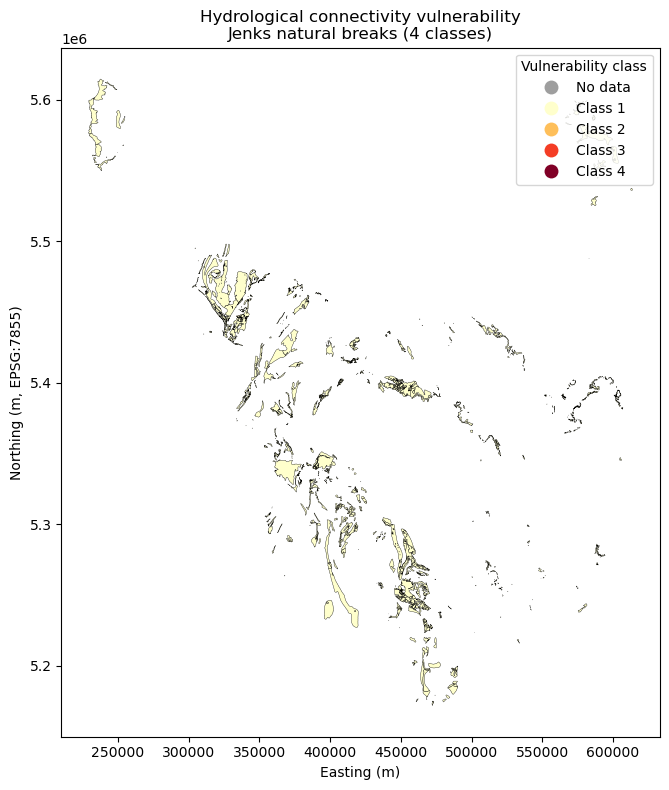

Classified polygon table saved: C:\Users\innoc\OneDrive - University of Tasmania\AT3_initial_datasets\Output_data\karst_upstream_connectivity_counts_tas_100m_EPSG7855_jenks4.csv
Classified polygon GeoPackage saved: C:\Users\innoc\OneDrive - University of Tasmania\AT3_initial_datasets\Output_data\karst_connectivity_vulnerability_tas_100m_EPSG7855.gpkg
Targets assigned No data: 132


In [21]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from IPython.display import display

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from IPython.display import display

JENKS_CLASS_COUNT = 4
ratio_column = "upstream_cells_per_target_cell"
score_column = "hydrological_connectivity_vulnerability_score"
class_column = "hydrological_connectivity_vulnerability_class"

counts_tas_100m_path = output_path / "karst_upstream_connectivity_counts_tas_100m_EPSG7855.csv"
counts_manifest_path = output_path / "karst_upstream_connectivity_counts_tas_100m_EPSG7855.cell.json"
if counts_manifest_path.is_file():
    try:
        manifest_counts_path = Path(json.loads(counts_manifest_path.read_text(encoding="utf-8"))["csv_path"])
        if manifest_counts_path.is_file():
            counts_tas_100m_path = manifest_counts_path
    except (OSError, ValueError, KeyError, TypeError):
        pass
if not counts_tas_100m_path.is_file():
    raise FileNotFoundError("Run the D8 recount cell first, or provide its saved counts CSV")
# Reload the exact CSV produced by Step 6 so an older in-memory table cannot be classified.
counts_tas_100m = pd.read_csv(counts_tas_100m_path)

ratio_values = pd.to_numeric(counts_tas_100m[ratio_column], errors="coerce").to_numpy(dtype="float64")
if {"upstream_cell_count", "target_raster_cells"}.issubset(counts_tas_100m.columns):
    numerator = pd.to_numeric(counts_tas_100m["upstream_cell_count"], errors="coerce").to_numpy(dtype="float64")
    denominator = pd.to_numeric(counts_tas_100m["target_raster_cells"], errors="coerce").to_numpy(dtype="float64")
    expected_ratio = np.divide(
        numerator, denominator, out=np.full(len(counts_tas_100m), np.nan), where=denominator > 0,
    )
    if not np.allclose(ratio_values, expected_ratio, rtol=1e-12, atol=1e-12, equal_nan=True):
        raise ValueError(
            f"{ratio_column} does not match upstream_cell_count / target_raster_cells "
            f"in {counts_tas_100m_path}"
        )
valid_ratio = np.isfinite(ratio_values)
if "target_raster_cells" in counts_tas_100m.columns:
    valid_ratio &= pd.to_numeric(counts_tas_100m["target_raster_cells"], errors="coerce").fillna(0).to_numpy() > 0
if not valid_ratio.any():
    raise ValueError(f"No finite values found in {ratio_column}")
if (ratio_values[valid_ratio] < 0).any():
    raise ValueError("Fixed-break classification expects non-negative connectivity ratios")

# Weighted exact Jenks optimization over unique ratios; equal values stay together.
unique_ratios, inverse_ratio, ratio_frequencies = np.unique(
    ratio_values[valid_ratio], return_inverse=True, return_counts=True,
)
unique_count = len(unique_ratios)
jenks_class_count = min(int(JENKS_CLASS_COUNT), unique_count)
if jenks_class_count < 1:
    raise ValueError("JENKS_CLASS_COUNT must be at least 1")

weights = ratio_frequencies.astype("float64")
weighted_values = unique_ratios * weights
weighted_squares = unique_ratios * unique_ratios * weights
prefix_weight = np.concatenate(([0.0], np.cumsum(weights)))
prefix_sum = np.concatenate(([0.0], np.cumsum(weighted_values)))
prefix_squares = np.concatenate(([0.0], np.cumsum(weighted_squares)))

def _jenks_segment_sse(start, stop):
    segment_weight = prefix_weight[stop] - prefix_weight[start]
    segment_sum = prefix_sum[stop] - prefix_sum[start]
    segment_squares = prefix_squares[stop] - prefix_squares[start]
    return max(0.0, segment_squares - segment_sum * segment_sum / segment_weight)

dp = np.full((jenks_class_count + 1, unique_count + 1), np.inf, dtype="float64")
backtrack = np.full((jenks_class_count + 1, unique_count + 1), -1, dtype="int32")
dp[0, 0] = 0.0
for class_count in range(1, jenks_class_count + 1):
    for stop in range(class_count, unique_count + 1):
        for start in range(class_count - 1, stop):
            candidate = dp[class_count - 1, start] + _jenks_segment_sse(start, stop)
            if candidate < dp[class_count, stop]:
                dp[class_count, stop] = candidate
                backtrack[class_count, stop] = start

jenks_segments = []
stop = unique_count
for class_count in range(jenks_class_count, 0, -1):
    start = int(backtrack[class_count, stop])
    if start < 0:
        raise RuntimeError("Could not recover the Jenks class boundaries")
    jenks_segments.append((start, stop))
    stop = start
jenks_segments.reverse()

class_for_unique_ratio = np.empty(unique_count, dtype="int16")
for score, (start, stop) in enumerate(jenks_segments, start=1):
    class_for_unique_ratio[start:stop] = score
scores = np.full(len(counts_tas_100m), np.nan, dtype="float64")
scores[valid_ratio] = class_for_unique_ratio[inverse_ratio]
counts_tas_100m_classified = counts_tas_100m.copy()
counts_tas_100m_classified[score_column] = pd.array(scores, dtype="Int64")
class_labels = ["No data"] + [f"Class {score}" for score in range(1, jenks_class_count + 1)]
class_values = np.full(len(counts_tas_100m), "No data", dtype=object)
class_values[valid_ratio] = [f"Class {int(score)}" for score in scores[valid_ratio]]
counts_tas_100m_classified[class_column] = pd.Categorical(
    class_values, categories=class_labels, ordered=True,
)

class_rows = []
for score, (start, stop) in enumerate(jenks_segments, start=1):
    class_rows.append({
        "vulnerability_score": score,
        "ratio_min": float(unique_ratios[start]),
        "ratio_max": float(unique_ratios[stop - 1]),
        "jenks_upper_break": float(unique_ratios[stop - 1]),
        "polygon_count": int(ratio_frequencies[start:stop].sum()),
    })
no_data_count = int((~valid_ratio).sum())
class_rows.append({
    "vulnerability_score": pd.NA,
    "ratio_min": np.nan,
    "ratio_max": np.nan,
    "jenks_upper_break": np.nan,
    "polygon_count": no_data_count,
})
jenks_class_summary = pd.DataFrame(class_rows)
jenks_class_summary["vulnerability_class"] = [
    "No data" if pd.isna(score) else f"Class {int(score)}"
    for score in jenks_class_summary["vulnerability_score"]
]
jenks_class_summary["ratio_range"] = jenks_class_summary.apply(
    lambda row: "No valid target cells" if pd.isna(row["ratio_min"])
    else f"{row['ratio_min']:.12g} to {row['ratio_max']:.12g}", axis=1,
)
jenks_class_summary = jenks_class_summary[[
    "vulnerability_class", "vulnerability_score", "ratio_range", "ratio_min", "ratio_max",
    "jenks_upper_break", "polygon_count",
]]

print(f"Jenks classes requested: {JENKS_CLASS_COUNT}; classes used: {jenks_class_count}")
display(jenks_class_summary)

classified_targets_tas_100m = gpd.read_file(karst_atlas_gpkg_path)
if classified_targets_tas_100m.crs is None:
    raise ValueError("Karst Atlas target polygons have no CRS")
if classified_targets_tas_100m.crs != dem_grid[1]:
    classified_targets_tas_100m = classified_targets_tas_100m.to_crs(dem_grid[1])
classified_ids = set(pd.to_numeric(counts_tas_100m_classified["target_objectid"], errors="coerce").dropna())
classified_targets_tas_100m = classified_targets_tas_100m.loc[
    pd.to_numeric(classified_targets_tas_100m["OBJECTID"], errors="coerce").isin(classified_ids)
].merge(
    counts_tas_100m_classified[["target_objectid", ratio_column, score_column, class_column]],
    left_on="OBJECTID", right_on="target_objectid", how="inner", validate="one_to_one",
)

fig, ax = plt.subplots(figsize=(10, 8))
score_cmap = plt.get_cmap("YlOrRd", jenks_class_count)
score_colors = [score_cmap(i) for i in range(jenks_class_count)]
class_cmap = ListedColormap(["#9e9e9e", *score_colors])
classified_targets_tas_100m.plot(
    column=class_column, categorical=True, cmap=class_cmap, legend=True,
    legend_kwds={"title": "Vulnerability class"},
    edgecolor="black", linewidth=0.25, ax=ax,
)
ax.set_title(f"Hydrological connectivity vulnerability\nJenks natural breaks ({jenks_class_count} classes)")
ax.set_xlabel("Easting (m)")
ax.set_ylabel(f"Northing (m, {dem_grid[1]})")
ax.set_aspect("equal", adjustable="box")
plt.tight_layout()
plt.show()

classified_counts_path = output_path / (
    f"karst_upstream_connectivity_counts_tas_100m_EPSG7855_jenks{jenks_class_count}.csv"
)
classified_gpkg_path = output_path / "karst_connectivity_vulnerability_tas_100m_EPSG7855.gpkg"
counts_tas_100m_classified.to_csv(classified_counts_path, index=False)
classified_targets_tas_100m.to_file(
    classified_gpkg_path, layer="hydrological_connectivity_vulnerability", driver="GPKG",
)
print(f"Classified polygon table saved: {classified_counts_path}")
print(f"Classified polygon GeoPackage saved: {classified_gpkg_path}")
print(f"Targets assigned No data: {no_data_count:,}")
